# Notebook 1: meet the data

M/EEG foundation models workshop · *Do foundation models beat classical EEG decoding?*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BabaSanfour/meeg-fm-workshop/blob/main/notebooks/01_data.ipynb)

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 0</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Setup</div><div style="font-size:0.85em; color:#5B6472;">check · install · download</div></td><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Meet the data</div><div style="font-size:0.85em; color:#C9D6E8;">BCI IV 2a · epochs · mu and beta rhythms</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Classical baselines</div><div style="font-size:0.85em; color:#5B6472;">CSP + LDA · tangent space</div></td></tr><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Frozen REVE</div><div style="font-size:0.85em; color:#5B6472;">embeddings · linear probe · few labels</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 4</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Fine-tuning</div><div style="font-size:0.85em; color:#5B6472;">demo · GPU optional</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 5</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Who won?</div><div style="font-size:0.85em; color:#5B6472;">one table · per person · statistics</div></td></tr></table>

Notebook 0 downloaded the data. A decoder, classical or pretrained, can only tell a left-hand trial from a right-hand trial if the EEG of the two differs. This notebook shows what that difference is, turns it into a few numbers a program can use, and trains a first small model on them. Looking at the signal, extracting features and training a model are the three steps of classical EEG decoding. They are also what a foundation model is meant to replace, so we need to know them before comparing.

| Part | Content |
|---|---|
| 1 | The experiment and the trials |
| 2 | What changes in the EEG: the mu and beta rhythms |
| 3 | All participants |
| 4 | From rhythms to features |
| 5 | A first model, trained on day 1 and tested on day 2 |
| 6 | Summary |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Three kinds of blocks</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;the code is complete: run the cell and read the comments.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complete the one or two lines marked <code>&lt;---</code>, with the hints.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;optional: write the cell yourself, from hints and links to the documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Each exercise is followed by a folded solution. Run the solution before moving on: the next cells use its variables. Type 3 blocks can wait until after the session. The code that draws the figures is in the tutorial package, <code>meeg_fm</code>, imported as <code>mf</code>.</div></div>

In [1]:
#@title Setup: install on Colab, imports, data folder
import sys
import importlib

REPO_URL = "https://github.com/BabaSanfour/meeg-fm-workshop"   # the tutorial repository
USE_DRIVE = True                                     # Colab: read the data that notebook 0 saved in your Google Drive

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q "git+{REPO_URL}.git"
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")                # a window asks for permission
    importlib.invalidate_caches()

try:
    import meeg_fm as mf                             # the tutorial package: data, figures, scoring
except ImportError:
    raise ImportError("The tutorial package is missing. Colab: Runtime › Restart session, then Run all. "
                      "Your computer: run `pip install -e .` in the repository folder, then restart the kernel.")

import numpy as np
import pandas as pd
import mne
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit

mne.set_log_level("ERROR")                           # MNE only prints errors
mf.plot.style()
DATA_DIR = mf.use_data_dir()                         # the folder notebook 0 filled
print("Data folder:", DATA_DIR)

Data folder: ~/mne_data


In [2]:
# ---- Parameters
SUBJECT = 1                                  # the participant of parts 1 and 2
SUBJECTS = list(range(1, 10))                # parts 3 to 5 (slow computer or 3 participants downloaded: [1, 2, 3])
BANDS = {"mu": (8, 13), "beta": (13, 30)}    # frequency bands, in Hz
FREQS = np.arange(4, 41)                     # frequencies of the time-frequency maps, in Hz
BASELINE = (-1.5, -0.5)                      # reference window before the cue, in seconds
IMAGERY = (0.5, 4.0)                         # window in which we measure the effect, in seconds

## 1. The experiment and the trials

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Nine people imagined moving their left or right hand, 144 times per day, on two days. One trial is 4 s of EEG on 22 electrodes.</div>

<div style="border-left:5px solid #5B6472; background:#F3F4F6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#5B6472;">Data</b><br><b>BCI Competition IV, data set 2a</b> (Tangermann et al., 2012), <code>BNCI2014_001</code> in MOABB. 9 people, 22 EEG electrodes, 250 samples per second. Each person came on <b>two days</b> and did 288 trials per day.</div>

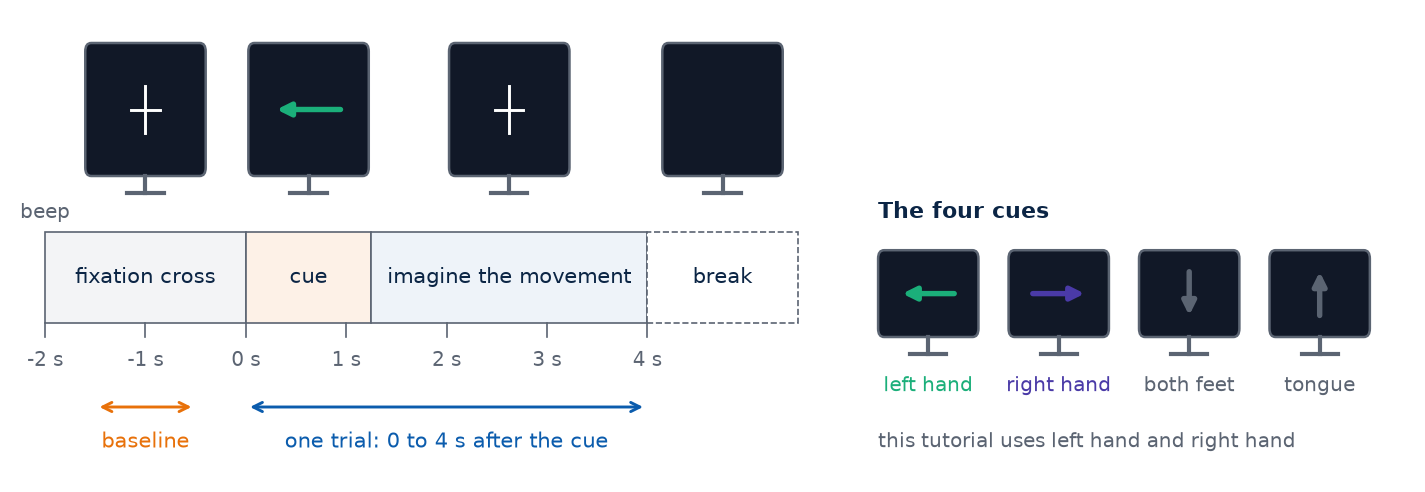

An arrow, the **cue**, tells the person which movement to imagine, without moving. An **epoch** (or trial) is the piece of recording cut around one cue; time 0 is the cue. The decoders get the 4 s after the cue. Here we also keep the 2 s before it, as a baseline.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Load the trials

`mf.load_epochs` asks MOABB for the left- and right-hand trials. With `return_epochs=True` it gives an MNE `Epochs` object, which has the plotting and spectral methods used below.

In [3]:
# ---- Left- and right-hand trials of one participant, from 2 s before the cue to 4 s after
epochs = mf.load_epochs([SUBJECT], fmin=1, fmax=40, tmin=-2, tmax=4, return_epochs=True)    # band-pass 1-40 Hz
print(epochs.get_data().shape, "(trials, channels, samples)")
pd.crosstab(epochs.metadata["session"], epochs.metadata["label"])     # trials per day and per movement

(288, 22, 1500) (trials, channels, samples)


label,left_hand,right_hand
session,,
0train,72,72
1test,72,72


72 trials per movement and per day, so guessing gives 50 %. `0train` is day 1 and `1test` is day 2.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Where the electrodes are

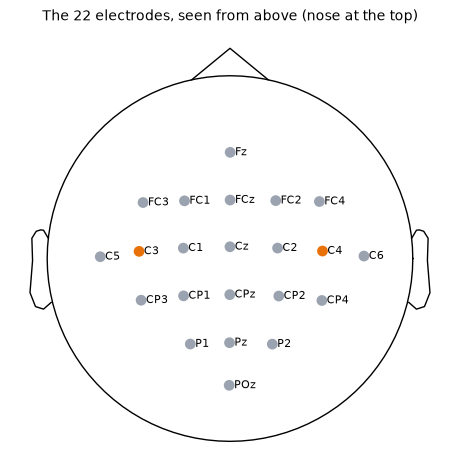

In [4]:
# ---- The 22 electrodes seen from above; C3 and C4 in orange
mf.plot.electrodes(highlight=["C3", "C4"])

The electrodes cover the centre of the head, above the **motor cortex**, the part of the brain that controls movement. Each hand is controlled by the opposite side of the brain. So we follow two electrodes: **C3**, over the left motor cortex (right hand), and **C4**, over the right motor cortex (left hand).

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>The person does not move. What could differ in the EEG between imagining the left hand and imagining the right hand, and where on this map would you look for it?</div>

## 2. What changes in the EEG: the mu and beta rhythms

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Imagining a hand movement weakens two rhythms over the motor cortex, mostly on the side opposite the hand. This is the signal every decoder of this tutorial relies on.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: alpha, mu, beta, ERD and ERS</b><br>The EEG is a mixture of <b>rhythms</b>: oscillations at different speeds, named by frequency band. <b>Alpha (8 to 13 Hz)</b> is the strongest rhythm of the resting brain. Over the back of the head it grows when the eyes are closed and is linked to visual attention. Over the motor cortex the same band is called <b>mu</b>: it is strong when the body is still and drops when you move a hand, or only imagine it, mostly over the hemisphere <b>opposite</b> the hand: C4 for the left hand, C3 for the right. This drop is called <b>event-related desynchronisation (ERD)</b> (Pfurtscheller and Lopes da Silva, 1999; Pfurtscheller and Neuper, 2001).<br><b>Beta (13 to 30 Hz)</b> is linked to motor control and to holding the current posture (Engel and Fries, 2010). It also drops during movement and imagery, and comes back above its resting level once the movement stops: the <b>beta rebound</b>, an <b>event-related synchronisation (ERS)</b>.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: why it matters</b><br>This matters for decoding because it gives a decoder something to measure. If mu and beta power is lower at C3 than at C4, the person probably imagined the right hand; if it is lower at C4, the left hand. A brain-computer interface built on motor imagery reads this difference, trial after trial.</div>

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out</b><br>All electrodes share one reference, behind the left ear, so C3 and C4 mostly show activity common to the whole head. The <b>current source density</b> (CSD; Perrin et al., 1989) keeps what is local to each electrode. Without this step the effect is hard to see in this dataset.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Power over time and frequency

A **time-frequency map** gives the power at each frequency and each moment of the trial, averaged over trials. We express it as a change from the baseline, in %: blue is a drop (ERD), red an increase (ERS).

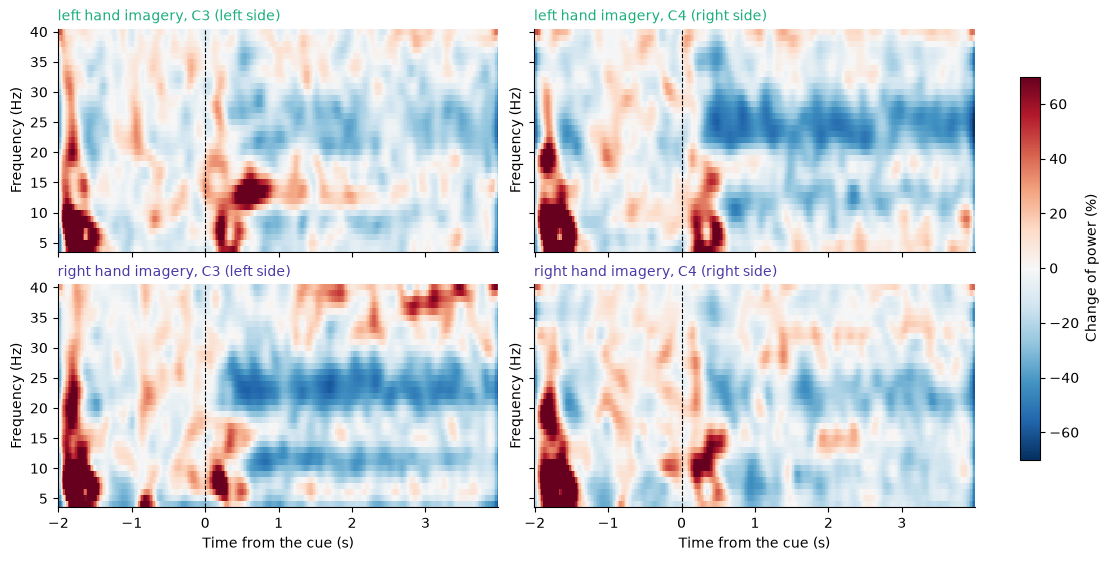

In [5]:
# ---- Time-frequency maps of each movement, as a % change from the baseline
def erd_maps(epochs, picks=None):
    """One time-frequency map per movement (Morlet wavelets), in % change from the baseline."""
    maps = {}
    for cls in mf.CLASSES:
        tfr = epochs[cls].compute_tfr("morlet", freqs=FREQS, n_cycles=FREQS / 2, average=True, decim=5, picks=picks)
        tfr.apply_baseline(BASELINE, mode="percent")
        tfr.data *= 100                                      # fraction -> %
        maps[cls] = tfr
    return maps


local = mne.preprocessing.compute_current_source_density(epochs)    # keep the local activity (see Watch out)
maps = erd_maps(local)
mf.plot.time_frequency(maps)

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With participant 1, two blue bands appear about half a second after the cue (dashed line) and last for the whole imagery: one near 10 to 13 Hz (mu) and one near 20 to 27 Hz (beta). They are darkest on the side opposite the hand: at C3 for the right hand, at C4 for the left hand, as described by Pfurtscheller and Neuper (2001). The red patches just after the beep (−2 s) and the cue are the brain's response to the sound and to the arrow.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The same on the whole head

`mf.plot.head_maps` averages a time-frequency map over one band and over the imagery period, and draws the result on the head. The dots are the electrodes; between and around them the colours are interpolated.

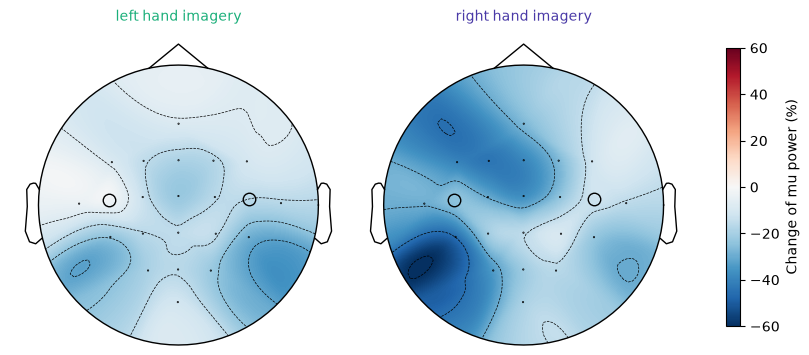

In [6]:
# ---- Change of mu power during imagery, at every electrode
mf.plot.head_maps(maps, {"mu": BANDS["mu"]}, IMAGERY)

With participant 1, the right hand gives a strong drop over the left side of the head, around C3 (left circle). The left hand gives a weaker drop on both sides, a little more around C4 (right circle). A decoder can use this difference between sides.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Another band

Draw the same two head maps for the **beta** band. Then try other bands: theta (4 to 8 Hz), low beta (13 to 20 Hz), high beta (20 to 30 Hz), gamma (30 to 40 Hz). In which bands does the drop change side with the hand?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br>A band is a pair (lowest frequency, highest frequency) in Hz, for example <code>(8, 13)</code>. <code>BANDS[&quot;beta&quot;]</code> is <code>(13, 30)</code>. The maps go from 4 to 40 Hz.</div>

In [7]:
# ---- Exercise: head maps of another band
band = ...                                           # <--- a pair (low, high) in Hz, for example BANDS["beta"]

if band is not ...:                                  # runs once the line above is completed
    mf.plot.head_maps(maps, {"your band": band}, IMAGERY)

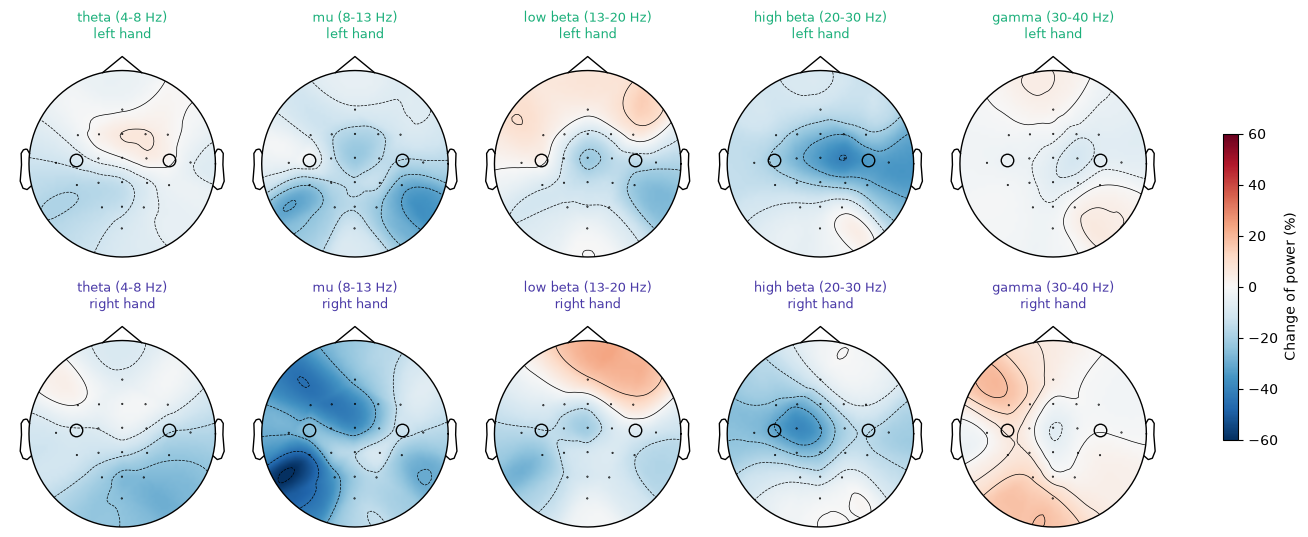

In [8]:
#@title Solution (try first)
# ---- Head maps of five bands, for each movement
ALL_BANDS = {"theta": (4, 8), "mu": (8, 13), "low beta": (13, 20), "high beta": (20, 30), "gamma": (30, 40)}
mf.plot.head_maps(maps, ALL_BANDS, IMAGERY)
# With participant 1 the drop changes side with the hand in mu and in both beta bands.
# Theta and gamma show no clear difference between sides.

## 3. All participants

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>The effect exists on average, but it is strong in some people and absent in others. This will decide which participants can be decoded.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Two numbers per participant

For each participant and band: the mean change of power during imagery at the electrode **opposite** the imagined hand, and at the electrode on the **same side**. About one minute.

In [9]:
# ---- Change of power at C3 and C4 for every participant: opposite side and same side
epochs_all = mf.load_epochs(SUBJECTS, fmin=1, fmax=40, tmin=-2, tmax=4, return_epochs=True)
local_all = mne.preprocessing.compute_current_source_density(epochs_all, copy=False)

OPPOSITE = [("left_hand", "C4"), ("right_hand", "C3")]           # electrode opposite the imagined hand
SAME = [("left_hand", "C3"), ("right_hand", "C4")]               # electrode on the side of the imagined hand

rows = []
for subject in SUBJECTS:
    maps_s = erd_maps(local_all[f"subject == {subject}"], picks=["C3", "C4"])
    for band, (low, high) in BANDS.items():
        change = {(cls, ch): maps_s[cls].get_data(picks=ch, fmin=low, fmax=high, tmin=IMAGERY[0], tmax=IMAGERY[1]).mean()
                  for cls in mf.CLASSES for ch in ["C3", "C4"]}
        rows.append({"band": band, "subject": subject,
                     "opposite": np.mean([change[pair] for pair in OPPOSITE]),
                     "same": np.mean([change[pair] for pair in SAME])})
summary = pd.DataFrame(rows).set_index(["band", "subject"])
summary.loc["mu"].round(0).T

subject,1,2,3,4,5,6,7,8,9
opposite,-20.0,16.0,-58.0,-9.0,1.0,-11.0,-43.0,-19.0,-43.0
same,-7.0,21.0,-34.0,2.0,-3.0,3.0,-43.0,-5.0,-39.0


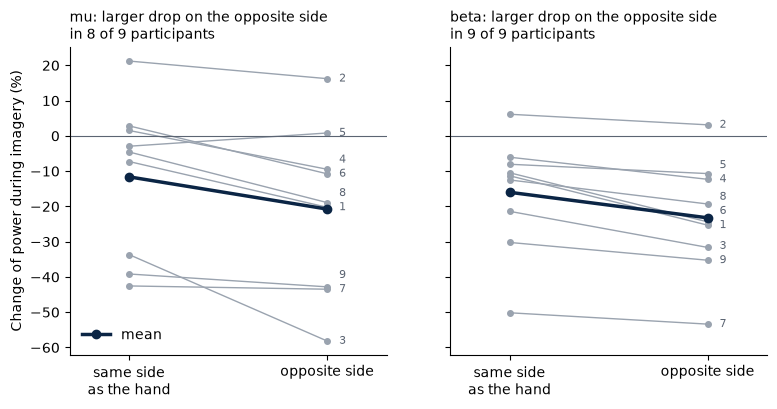

In [10]:
# ---- One line per participant: change of power on the same side and on the opposite side
mf.plot.sides(summary)

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>The numbers on the right are the participants. On average the power drops more on the opposite side, but people differ a lot: some lose more than half of their mu power, some show no drop at all. This is well known in motor-imagery BCI (Blankertz et al., 2010). Expect every decoder to work well for some participants and poorly for others.</div>

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>From this figure, which participants do you expect to be easy to decode, and which hard? Write your guess down: notebook 2 gives the answer.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> A participant without a drop

Draw the time-frequency maps of a participant whose power does not drop, and compare with participant 1.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br>The table above shows who has no drop: look for values close to 0 or positive. <code>local_all[&quot;subject == 5&quot;]</code> selects the trials of participant 5; the text between quotes is a condition on the columns of <code>local_all.metadata</code>.</div>

In [11]:
# ---- Exercise: time-frequency maps of a participant without a drop
chosen = ...                                         # <--- the trials of one participant: local_all["subject == ..."]

if chosen is not ...:                                # runs once the line above is completed
    mf.plot.time_frequency(erd_maps(chosen, picks=["C3", "C4"]))

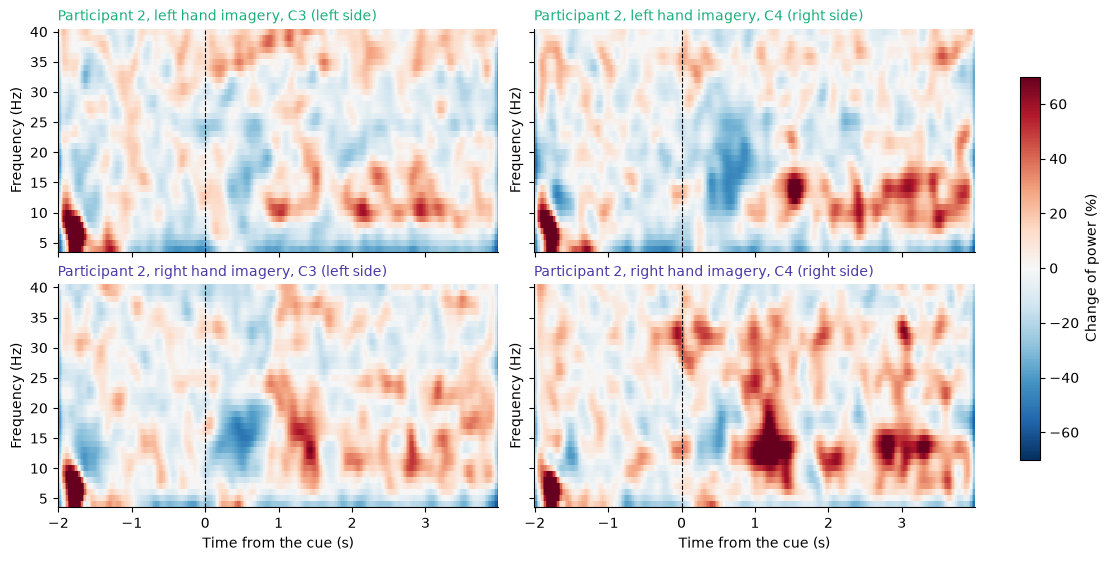

In [12]:
#@title Solution (try first)
# ---- Time-frequency maps of the participant with the smallest mu drop
weakest = summary.loc["mu"]["opposite"].idxmax()
chosen = local_all[f"subject == {weakest}"]
mf.plot.time_frequency(erd_maps(chosen, picks=["C3", "C4"]), title=f"Participant {weakest}, ")
# With all 9 participants this is participant 2: no lasting blue band at either electrode, for either hand,
# and mu power even rises during imagery. There is little here that tells the two hands apart.

## 4. From rhythms to features

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>A program needs numbers. We summarise each trial by four numbers chosen from what we know of the physiology: the power of mu and of beta, at C3 and at C4.</div>

So far we looked at averages over many trials. A decoder has to decide for **one trial at a time**, and it cannot look at a figure. Classical EEG decoding does this in three steps.

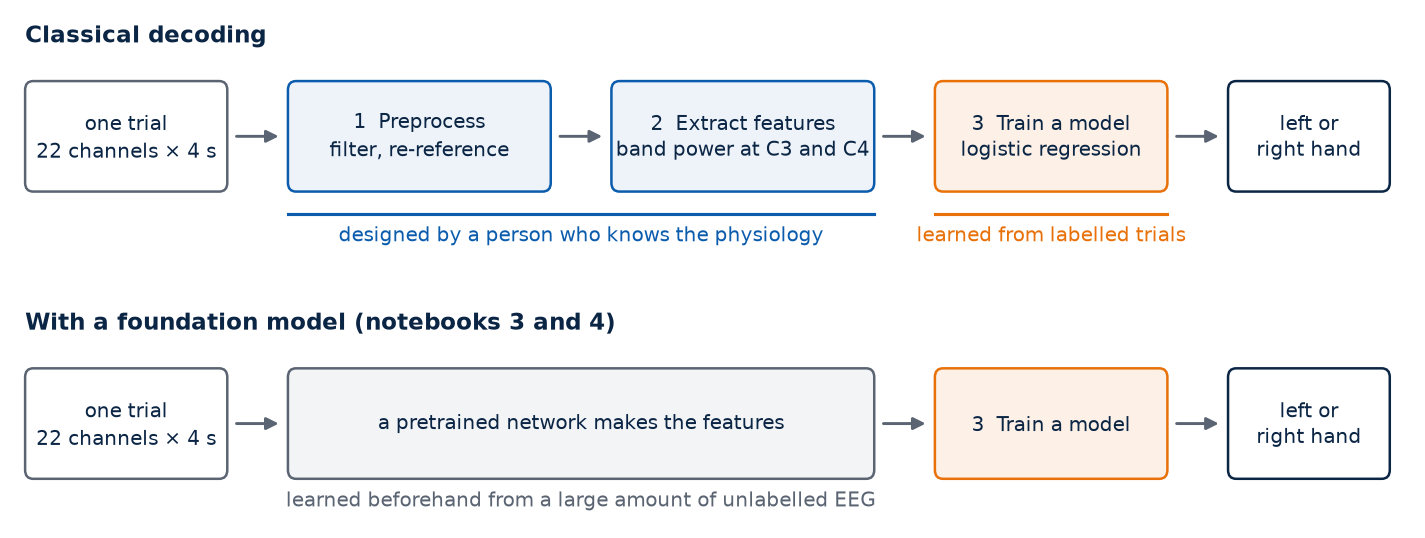

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: preprocess, extract features, train a model</b><br><b>1. Preprocess.</b> Keep the part of the signal where the effect is: a band-pass filter, a reference that keeps local activity.<br><b>2. Extract features.</b> Summarise each trial by a few numbers, the <b>features</b>, chosen by someone who knows where the information is. Here: how strong the mu and beta rhythms were at C3 and C4 during the imagery.<br><b>3. Train a model.</b> A <b>model</b> (or <b>classifier</b>) learns from trials whose answer we know how to go from the features to the answer, left or right. This is <b>machine learning</b>: the rule is learned from examples, not written by hand.<br>Steps 1 and 2 are where a person puts knowledge of the brain into the decoder. For decades, progress in EEG decoding meant better features. A foundation model replaces these two steps with a network that has learned its own features from a large amount of EEG. Whether those learned features are better than hand-made ones is the question of this tutorial.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Four features per trial

The **power** of a rhythm in a trial is the variance of the signal once it is filtered in the band. We take its logarithm, which spreads the values more evenly.

In [13]:
# ---- One row per trial, four features: log power of mu and beta at C3 and C4 during imagery
def band_power(epochs, band):
    """Log power in a band at C3 and C4 during imagery (trials x 2)."""
    signal = epochs.copy().pick(["C3", "C4"]).filter(*band).crop(tmin=IMAGERY[0]).get_data()
    return np.log(signal.var(axis=-1))


features = pd.DataFrame(np.hstack([band_power(local_all, BANDS["mu"]), band_power(local_all, BANDS["beta"])]),
                        columns=["mu C3", "mu C4", "beta C3", "beta C4"])
meta = epochs_all.metadata
y = meta["label"].to_numpy()                                     # the answer for each trial: "left_hand" or "right_hand"
print("features:", features.shape, "(trials, features)")
features.assign(label=y).head(4).round(2)

features: (2592, 4) (trials, features)


,mu C3,mu C4,beta C3,beta C4,label
0,-12.95,-12.55,-12.39,-11.91,right_hand
1,-11.50,-12.30,-11.56,-11.94,left_hand
2,-11.76,-12.83,-11.58,-12.01,left_hand
3,-12.68,-12.26,-12.39,-11.98,right_hand


Each trial went from 22 × 1500 numbers to 4. The table shows the first four trials with their label.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Do the features separate the two hands?

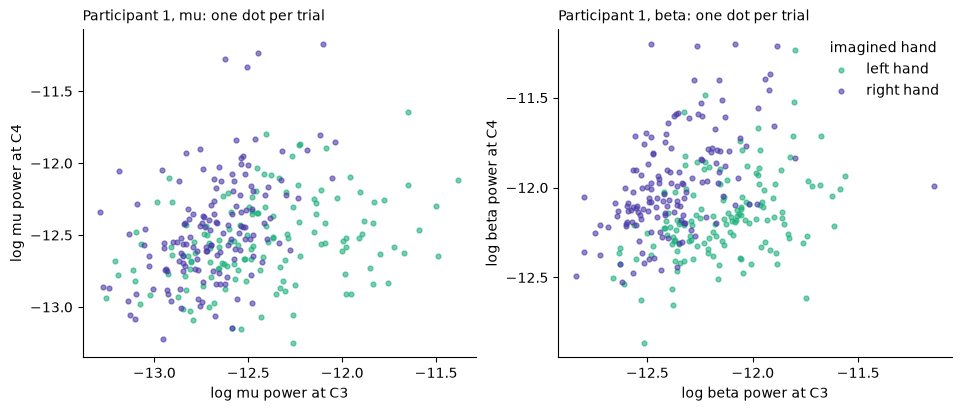

In [14]:
# ---- The trials of one participant in the plane of two features
person = (meta["subject"] == SUBJECT).to_numpy()
mf.plot.feature_planes(features[person], y[person], BANDS, title=f"Participant {SUBJECT}, ")

With participant 1 the two colours overlap, more in mu than in beta. In each panel the right-hand trials sit towards the upper left: less power at C3, more at C4. No feature separates the two hands on its own. A model has to combine them.

## 5. A first model, trained on day 1 and tested on day 2

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>A model learns a rule from the trials of day 1 and is judged on the trials of day 2, which it has never seen. Four hand-made features and a simple model already decode several participants.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: training set, test set, and the split of this tutorial</b><br>A model is <b>trained</b> on some trials and <b>tested</b> on others. If we tested it on the trials it learned from, we would measure its memory, not its ability to decode new trials.<br>Here we train on <b>day 1</b> and test on <b>day 2</b>, separately for each participant. EEG changes from one day to the next, and a brain-computer interface is always used after it was trained. Mixing the trials of both days at random would let the model see day 2 during training and give a score that is too high: <b>data leakage</b>.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The split in code

One mask per set. Every later notebook builds the same two masks.

In [15]:
# ---- Day 1 for training, day 2 for testing
train = (meta["session"] == "0train").to_numpy()                 # day 1
test = (meta["session"] == "1test").to_numpy()                   # day 2
print(f"Participant {SUBJECT}: {(person & train).sum()} trials to train on, {(person & test).sum()} to test on")

Participant 1: 144 trials to train on, 144 to test on


<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: a model and its weights</b><br><b>Logistic regression</b> is one of the simplest models. It gives each feature a <b>weight</b>, adds up the weighted features, and turns the sum into a probability of <i>right hand</i>. Training means finding the weights that give the highest probability to the correct answers of the training trials. In scikit-learn every model is used the same way: <code>model.fit(features, answers)</code> to train, <code>model.predict(features)</code> to get answers for new trials.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Train the model and test it

Train a logistic regression on the day-1 trials of participant `SUBJECT`, then compute the proportion of correct answers on day 2.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br>The day-1 rows of this participant are <code>features[person &amp; train]</code> and <code>y[person &amp; train]</code>; replace <code>train</code> by <code>test</code> for day 2. <code>balanced_accuracy_score(true_answers, predicted_answers)</code> gives the proportion of correct answers, averaged over the two hands.</div>

In [16]:
# ---- Exercise: fit the model on day 1, score it on day 2
model = LogisticRegression()
fitted = ...                                         # <--- model.fit(features of day 1, answers of day 1)
accuracy = ...                                       # <--- balanced_accuracy_score(answers of day 2, model.predict(features of day 2))

In [17]:
#@title Solution (try first)
# ---- Fit the model on day 1, score it on day 2
model = LogisticRegression()
model.fit(features[person & train], y[person & train])
accuracy = balanced_accuracy_score(y[person & test], model.predict(features[person & test]))
print(f"Participant {SUBJECT}: {100 * accuracy:.0f} % of day-2 trials correct (chance: 50 %)")

Participant 1: 79 % of day-2 trials correct (chance: 50 %)


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> What did the model learn?

The weights say how the model uses each feature. A positive weight pushes the answer towards "right hand" when the feature is high, a negative weight towards "left hand".

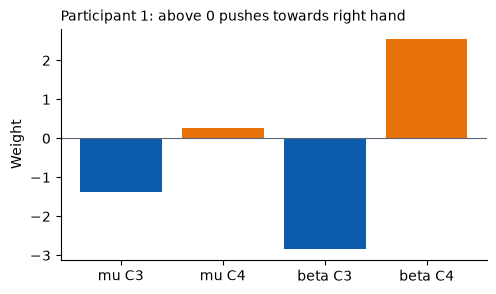

In [18]:
# ---- The weight the model gave to each feature
weights = pd.Series(model.coef_[0], index=features.columns)
mf.plot.weights(weights, title=f"Participant {SUBJECT}: above 0 pushes towards right hand")

With participant 1 the model gives negative weights to the power at C3 and positive weights to the power at C4, mostly in beta. In words: low power at C3 together with high power at C4 means right hand. The model found, from the labels alone, the rule that the physiology predicts: the rhythm drops on the side opposite the hand.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The same for every participant

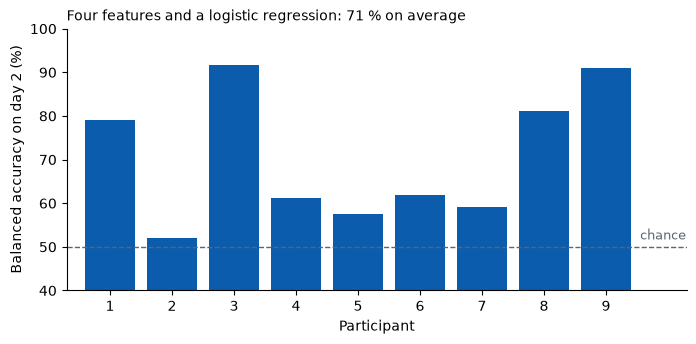

In [19]:
# ---- One model per participant: trained on day 1, tested on day 2
def day2_accuracy(subject, columns=features.columns):
    """Balanced accuracy on day 2 of a logistic regression trained on day 1 of one participant."""
    person = (meta["subject"] == subject).to_numpy()
    model = LogisticRegression().fit(features.loc[person & train, columns], y[person & train])
    return 100 * balanced_accuracy_score(y[person & test], model.predict(features.loc[person & test, columns]))


scores = pd.Series({subject: day2_accuracy(subject) for subject in SUBJECTS})
mf.plot.scores(scores, title=f"Four features and a logistic regression: {scores.mean():.0f} % on average")

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>Four numbers per trial and one of the simplest models give 71 % on average: 79 % or more for participants 1, 3, 8 and 9, and close to chance for 2, 5 and 7. The participants near chance are those of part 3 whose rhythms did not differ between sides. This is a complete classical decoder, small but real. Notebook 2 keeps the model and improves the features: instead of two electrodes chosen by hand, it learns how to combine all 22.</div>

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>Participant 7 had one of the largest drops of power in part 3, and is decoded at 59 %. Why? Look again at the two numbers of this participant in the table of part 3.</div>

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> Which features matter?

Train the same model on the two mu features only, then on the two beta features only. Which band carries more? Is it the same for every participant?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>day2_accuracy(subject, columns=[&quot;mu C3&quot;, &quot;mu C4&quot;])</code> trains on a subset of the features. Build a table with one column per set of features and one row per participant.</div>

In [20]:
# ---- Type 3: the model with the mu features only, and with the beta features only (optional)

In [21]:
#@title Solution (try first)
# ---- The model with the mu features only, with the beta features only, and with all four
sets = {"mu only": ["mu C3", "mu C4"], "beta only": ["beta C3", "beta C4"], "all four": list(features.columns)}
by_features = pd.DataFrame({name: [day2_accuracy(s, columns) for s in SUBJECTS] for name, columns in sets.items()},
                           index=SUBJECTS).T
by_features["mean"] = by_features.mean(axis=1)
by_features.round(0)
# With the 9 participants: 68 % with mu only, 70 % with beta only, 71 % with all four.
# People differ: participant 3 is decoded from mu (92 % against 85 %), participants 6 and 7 from beta.

,1,2,3,4,5,6,7,8,9,mean
mu only,75.0,54.0,92.0,61.0,58.0,56.0,51.0,78.0,86.0,68.0
beta only,74.0,53.0,85.0,62.0,65.0,67.0,61.0,76.0,90.0,70.0
all four,79.0,52.0,92.0,61.0,58.0,62.0,59.0,81.0,91.0,71.0


### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> What would a random split have shown?

Instead of training on day 1 and testing on day 2, mix the trials of both days and train on a random half. Compare the scores. Which participants change most?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>StratifiedShuffleSplit(n_splits=5, train_size=0.5, random_state=0).split(X, y)</code> gives five random halves with as many left- as right-hand trials (<a href='https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html'>documentation</a>). Use the rows of one participant from both days, and average the five scores.</div>

In [22]:
# ---- Type 3: the same model with a random half of both days as training set (optional)

In [23]:
#@title Solution (try first)
# ---- The same model with a random half of both days as training set
def random_split_accuracy(subject, n_draws=5):
    """Mean balanced accuracy over random 50/50 splits of the trials of both days."""
    person = (meta["subject"] == subject).to_numpy()
    X_p, y_p = features[person].to_numpy(), y[person]
    draws = StratifiedShuffleSplit(n_splits=n_draws, train_size=0.5, random_state=0).split(X_p, y_p)
    return 100 * np.mean([balanced_accuracy_score(y_p[b], LogisticRegression().fit(X_p[a], y_p[a]).predict(X_p[b]))
                          for a, b in draws])


splits = pd.DataFrame({"train day 1, test day 2": scores,
                       "random split of both days": [random_split_accuracy(s) for s in SUBJECTS]}).T
splits["mean"] = splits.mean(axis=1)
splits.round(0)
# With this small model the mean does not change (71 %), but single participants do: 7 gains 13 points with the
# random split and 9 loses 11. Notebook 2 repeats the comparison with stronger decoders, where the random split
# scores higher on average.

,1,2,3,4,5,6,7,8,9,mean
"train day 1, test day 2",79.0,52.0,92.0,61.0,58.0,62.0,59.0,81.0,91.0,71.0
random split of both days,77.0,53.0,90.0,58.0,63.0,68.0,72.0,81.0,80.0,71.0


## 6. Summary

| Step | Function | Package |
|---|---|---|
| Trials as an `Epochs` object | `mf.load_epochs(..., return_epochs=True)` | MOABB, MNE |
| Electrode map | `mf.plot.electrodes` (`mne.viz.plot_sensors`) | MNE |
| Local activity | `mne.preprocessing.compute_current_source_density` | MNE |
| Time-frequency map | `epochs.compute_tfr`, `tfr.apply_baseline`, `tfr.plot` | MNE |
| Head map of a band | `mf.plot.head_maps` (`mne.viz.plot_topomap`) | MNE |
| Features: band power per trial | `epochs.filter`, `epochs.crop`, variance | MNE, NumPy |
| Train/test split | `metadata["session"] == "0train"` | pandas |
| Model | `LogisticRegression`, `fit`, `predict` | scikit-learn |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">Take-aways</b><br><ul style='margin:0;'><li>Imagining a hand movement lowers mu and beta power over the motor cortex, more on the side opposite the hand. The effect is clear in some participants and absent in others.</li><li>Classical decoding has three steps: preprocess, extract features chosen by hand, train a model on labelled trials. A foundation model replaces the first two.</li><li>Four hand-made features and a logistic regression reach 71 % on day 2 on average, from chance to above 90 % depending on the person.</li><li>Train on day 1, test on day 2. Nothing is fitted on day 2.</li></ul></div>

**Next**: `02_classical.ipynb`.

<details><summary>References</summary>

- Blankertz, B., Sannelli, C., Halder, S., Hammer, E. M., Kübler, A., Müller, K.-R., Curio, G., & Dickhaus, T. (2010). Neurophysiological predictor of SMR-based BCI performance. *NeuroImage, 51*(4), 1303-1309. https://doi.org/10.1016/j.neuroimage.2010.03.022
- Engel, A. K., & Fries, P. (2010). Beta-band oscillations: signalling the status quo? *Current Opinion in Neurobiology, 20*(2), 156-165. https://doi.org/10.1016/j.conb.2010.02.015
- Gramfort, A., Luessi, M., Larson, E., Engemann, D. A., Strohmeier, D., Brodbeck, C., ... Hämäläinen, M. (2013). MEG and EEG data analysis with MNE-Python. *Frontiers in Neuroscience, 7*, 267. https://doi.org/10.3389/fnins.2013.00267
- Jayaram, V., & Barachant, A. (2018). MOABB: Trustworthy algorithm benchmarking for BCIs. *Journal of Neural Engineering, 15*(6), 066011. https://doi.org/10.1088/1741-2552/aadea0
- Perrin, F., Pernier, J., Bertrand, O., & Echallier, J. F. (1989). Spherical splines for scalp potential and current density mapping. *Electroencephalography and Clinical Neurophysiology, 72*(2), 184-187. https://doi.org/10.1016/0013-4694(89)90180-6
- Pfurtscheller, G., & Lopes da Silva, F. H. (1999). Event-related EEG/MEG synchronization and desynchronization: Basic principles. *Clinical Neurophysiology, 110*(11), 1842-1857. https://doi.org/10.1016/S1388-2457(99)00141-8
- Pfurtscheller, G., & Neuper, C. (2001). Motor imagery and direct brain-computer communication. *Proceedings of the IEEE, 89*(7), 1123-1134. https://doi.org/10.1109/5.939829
- Tangermann, M., Müller, K.-R., Aertsen, A., Birbaumer, N., Braun, C., Brunner, C., ... Blankertz, B. (2012). Review of the BCI Competition IV. *Frontiers in Neuroscience, 6*, 55. https://doi.org/10.3389/fnins.2012.00055
</details>